### TODOS
- Do analysis short vs. long sequences
- Length comparison how well does whisper legnth correlate with real length
- Are short sequences more often wrong than long sequences?
- F1 at predicting short sequences vs long sequences
- LLM with context
- fix space and casing issue

In [14]:
import pandas as pd
import os
from tqdm.auto import tqdm
from llm_asr_clarification.constants import SAMPLE_MEETINGS
import json
import torch
import torch.nn.functional as F
from rouge_score import rouge_scorer
from transformers import AutoTokenizer

pd.set_option('display.max_colwidth', None)

AMI_PATH = '/group/jrwhitehill/amicorpus/train'
meeting_paths = [entry.path for entry in os.scandir(AMI_PATH)]
TRANSCRIPT_FILE = "whisper_tiny_diarized_transcript"

ALPHA = 3.0
THRESHOLD = 0.7

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"   # or another causal LM
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
scorer = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

def rouge_l(pred, ref):
    return scorer.score(
        ref,   # reference first
        pred   # prediction second
    )["rougeL"]

data = []
for meeting_path in tqdm(meeting_paths):
    beam_results = os.path.join(meeting_path, "artifacts", f"beam_results.json")
    try:
        with open(beam_results, "r", encoding="utf-8") as f:
            lines = f.read()
        lines = json.loads(lines)
    except Exception as err:
        print(f"couldnt open file {beam_results}")

    for line in lines:
        for i in range(1,6):
            beam_no = f'beam_{i}'
            beam = line.pop(beam_no)

            line[f"{beam_no}_text"] = beam["text"]
            line[f"{beam_no}_asrlogprob"] = beam["asr_avg_log_prob"]
            line[f"{beam_no}_llmlogprob"] = beam["llm_avg_log_prob"]
            
df = pd.DataFrame(lines)

100%|██████████| 136/136 [00:01<00:00, 133.58it/s]


In [15]:
llm_logprob_columns = [f'beam_{i}_llmlogprob' for i in range(1,6)]
asr_logprob_columns = [f'beam_{i}_asrlogprob' for i in range(1,6)]

llm_logprobs = torch.tensor(df[llm_logprob_columns].values)
asr_logprobs = torch.tensor(df[asr_logprob_columns].values)

# scores = F.softmax(ALPHA*llm_logprobs + 0.0asr_logprobs, dim=1)
scores = llm_logprobs

# highest_score_idxs = torch.argmax(scores, dim=1, keepdim=True)
# highest_scores = torch.gather(scores, dim=1, index=highest_score_idxs)
highest_scores = scores[torch.arange(scores.size(0)), torch.zeros(scores.size(0), dtype=torch.long)]
print(min(highest_scores))


tensor(-27.8750, dtype=torch.float64)


In [16]:
df['highest_score'] = highest_scores.numpy()
df['text'] = df['beam_1_text']
df['num_tokens'] = df['beam_1_text'].apply(
    lambda x: len(tokenizer.encode(x))
)
df['pred_mistranscription'] = df['highest_score'] < THRESHOLD

df["rougeL"] = [
    rouge_l(pred, ref).fmeasure
    for pred, ref in zip(df["text"], df["gt"])
]

In [17]:
df.head()

,gt,beam_1_text,beam_1_asrlogprob,beam_1_llmlogprob,beam_2_text,beam_2_asrlogprob,beam_2_llmlogprob,beam_3_text,beam_3_asrlogprob,beam_3_llmlogprob,...,beam_4_asrlogprob,beam_4_llmlogprob,beam_5_text,beam_5_asrlogprob,beam_5_llmlogprob,highest_score,text,num_tokens,pred_mistranscription,rougeL
0,Hello.,Hello,-0.499981,-16.62500,Hello.,-0.166628,-10.25000,Hello.,-0.166628,-10.2500,...,-0.166628,-10.25000,Hello!,-0.749961,-9.25000,-16.62500,Hello,2,True,1.0
1,..,I need to go there.,-0.825584,-8.00000,I think we are going to need to go.,-1.653785,-5.71875,But I'm gonna throw the ball away.,-1.753428,-5.8750,...,-64.277092,-25.62500,I'm gonna get back to the hospital.,-0.878668,-6.37500,-8.00000,I need to go there.,7,True,0.0
2,"Yes, I made it.","Yes, I made it.",-0.060835,-5.09375,"Yes, I made it.",-0.060835,-5.09375,Yes I made it,-0.627244,-7.4375,...,-0.239422,-5.68750,"Yes, I made it.",-0.060835,-5.09375,-5.09375,"Yes, I made it.",7,True,1.0
3,English from now on.,English from now on.,-0.135894,-7.75000,English from now on,-0.304503,-9.25000,English from now on.,-0.135894,-7.7500,...,-0.257963,-9.12500,English from that one,-0.427362,-10.43750,-7.75000,English from now on.,6,True,1.0
4,. Just kidding.,Drawing or just testing. And we're going to bring that out of all the stress. Just kidding.,-0.698395,-5.03125,"Drawing or just testing? Yeah. We're going to bring you some more. That's all the stress. No. Just kidding. Oh, English.",-0.311134,-4.56250,"Drawing or just testing? Yeah, we're going to go in there. That's all the stress. Just kidding. I don't know.",-0.453075,-4.0625,...,-0.725123,-5.15625,Drawing or... Just testing? Yeah. I'm going to bring you some more. Hmm? It's all the stress. No. Just kidding. I'm English.,-0.384491,-4.59375,-5.03125,Drawing or just testing. And we're going to bring that out of all the stress. Just kidding.,22,True,0.2


# filtering for actual long utterances

<Axes: >

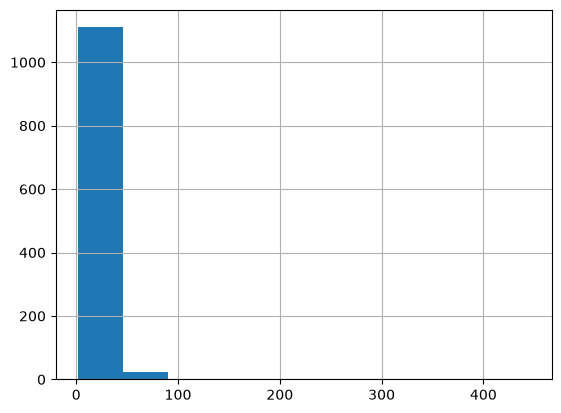

In [34]:
df['num_tokens'].hist(bins=10)

In [47]:
sum(df['num_tokens']>2)/len(df)

0.7889182058047494

In [48]:
# Filter out for only actual phrases not just 'ummm' and 'ahhh' and 'yeahh'

filtered_df = df[df['num_tokens'] > 5]

In [51]:
# min_score = min(df['highest_score'])
# range_score = max(df['highest_score']) - min_score
# df['normalized_score'] = (df['highest_score'] - min_score)/range_score

def standardize_df(datfram):
    datfram['normalized_score'] = (
        datfram['highest_score'] - datfram['highest_score'].mean()
    )/datfram['highest_score'].std()

standardize_df(df)
standardize_df(filtered_df)

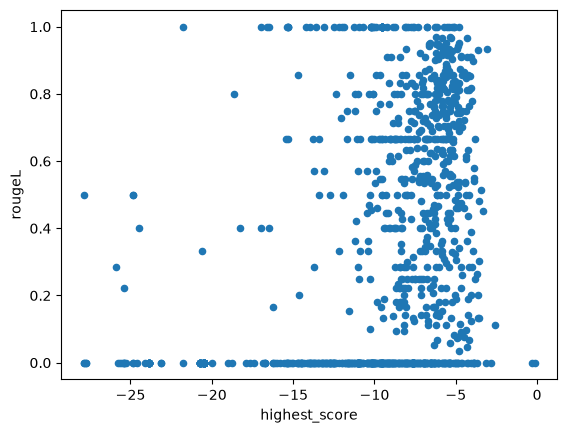

Pearson r: 0.4782
P-value: 0.0000


In [52]:
import matplotlib.pyplot as plt

df.plot.scatter(x='highest_score', y='rougeL')

# Display the plot
plt.show()

from scipy.stats import pearsonr

result = pearsonr(df['highest_score'], df['rougeL'])

print(f"Pearson r: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4f}")

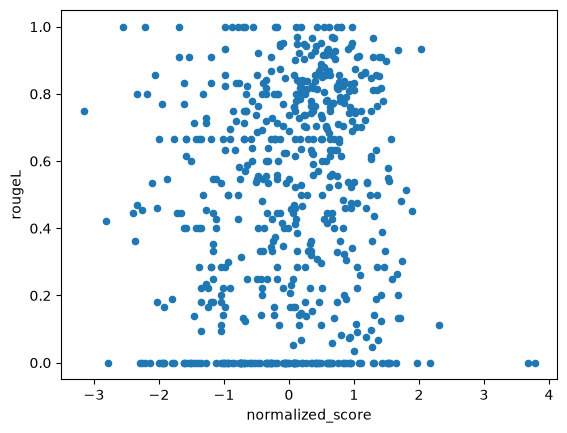

Pearson r: 0.1104
P-value: 0.0068


In [53]:
import matplotlib.pyplot as plt

filtered_df.plot.scatter(x='normalized_score', y='rougeL')

# Display the plot
plt.show()

from scipy.stats import pearsonr

result = pearsonr(filtered_df['normalized_score'], filtered_df['rougeL'])

print(f"Pearson r: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4f}")

In [ ]:
import matplotlib.pyplot as plt

filtered_df.plot.scatter(x='normalized_score', y='rougeL')

# Display the plot
plt.show()

from scipy.stats import pearsonr

result = pearsonr(filtered_df['normalized_score'], filtered_df['rougeL'])

print(f"Pearson r: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4f}")

<Axes: >

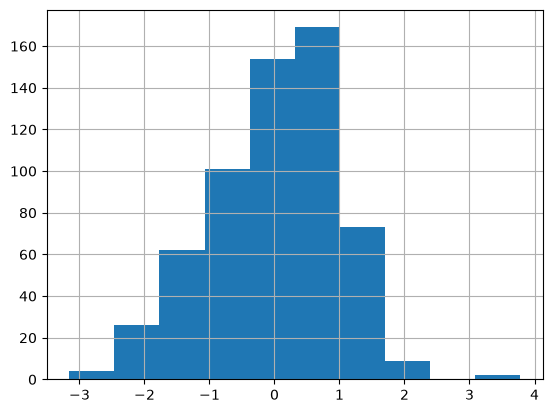

In [54]:
filtered_df['normalized_score'].hist()

<Axes: >

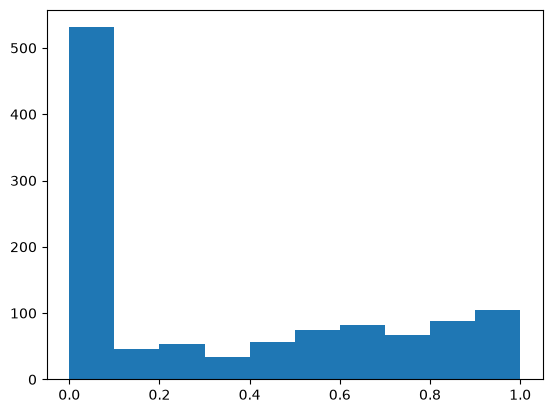

In [112]:
df['rougeL'].hist(grid=False, bins=10)

<Axes: >

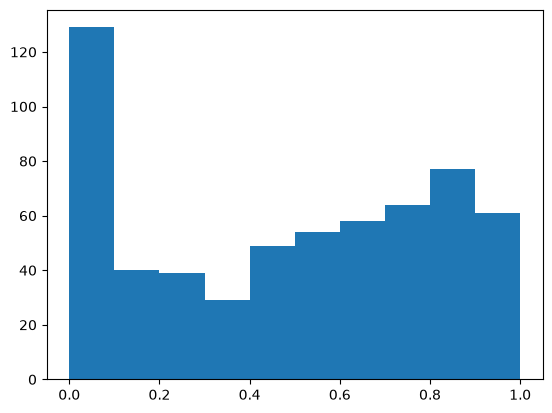

In [74]:
filtered_df['rougeL'].hist(grid=False, bins=10)

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score


def elbow_plot(
    df,
    log_prob_range=-10.0,
    mistranscription_label_threshold=0.3,
    metric_to_use="rougeL",
):
    """
    Plot F1 score for mistranscription detection as a function
    of avg_logprob threshold.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
            - avg_logprob
            - rougeL
            - rougeL_prec

    log_prob_range : float
        Lowest threshold to consider. Thresholds are swept from
        log_prob_range up to the maximum observed avg_logprob.

    mistranscription_label_threshold : float
        Ground-truth label threshold.

    metric_to_use : str
        Either 'rougeL' or 'rougeL_prec'
    """

    assert metric_to_use in ["rougeL", "rougeL_prec"]

    df = df.dropna(
        subset=["normalized_score", metric_to_use]
    ).copy()

    # Ground-truth labels
    y_true = (
        df[metric_to_use]
        < mistranscription_label_threshold
    ).astype(int)

    thresholds = np.linspace(
        log_prob_range,
        df["normalized_score"].max(),
        200,
    )

    f1s = []
    precs = []
    recs = []

    roc_auc = roc_auc_score(y_true, df["normalized_score"])
    
    for thresh in thresholds:
        y_pred = (
            (df["normalized_score"] < thresh)
        ).astype(int)

        f1s.append(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        precs.append(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

        recs.append(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        )

    best_idx = np.argmax(f1s)

    best_threshold = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    best_prec = precs[best_idx]
    best_rec = recs[best_idx]

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1s)

    plt.axvline(
        best_threshold,
        linestyle="--",
        alpha=0.7,
        label=f"best={best_threshold:.2f}",
    )

    plt.scatter(
        [best_threshold],
        [best_f1],
    )

    plt.xlabel("avg_logprob threshold")
    plt.ylabel("F1")
    plt.title(
        f"Mistranscription Detection\n"
        f"metric={metric_to_use}, "
        f"label threshold={mistranscription_label_threshold}"
    )

    plt.legend()
    plt.grid(True)

    print(
        f"Best threshold: {best_threshold:.4f}\n"
        f"ROCAUC: {roc_auc}\n"
        f"Best F1: {best_f1:.4f}\n"
        f"Precision at best F1: {best_prec:.4f}\n"
        f"Recall at best F1: {best_rec:.4f}\n"
    )

    plt.show()

    # return {
    #     "best_threshold": best_threshold,
    #     "best_f1": best_f1,
    #     "thresholds": thresholds,
    #     "f1s": f1s,
    # }

In [60]:
pd.set_option('display.max_colwidth', None)

In [61]:
rougeL_fifty = df['rougeL'].quantile(0.5)
print(f"50th quartile for rougeL is: {rougeL_fifty:.2f}")
rougeL_twentyfive = df['rougeL'].quantile(0.25)
print(f"25th quartile for rougeL is: {rougeL_twentyfive:.2f}")

50th quartile for rougeL is: 0.18
25th quartile for rougeL is: 0.00


Best threshold: 0.7537
ROCAUC: 0.2631811217692513
Best F1: 0.7751
Precision at best F1: 0.7194
Recall at best F1: 0.8403



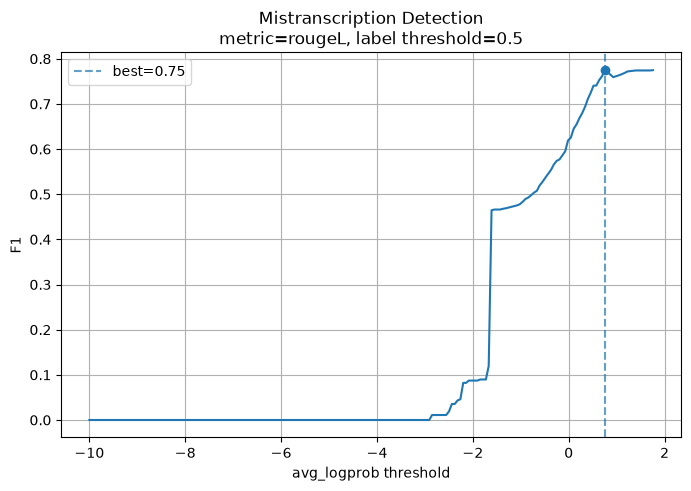

In [71]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: 3.7104
ROCAUC: 0.429340563894704
Best F1: 0.6441
Precision at best F1: 0.4758
Recall at best F1: 0.9965



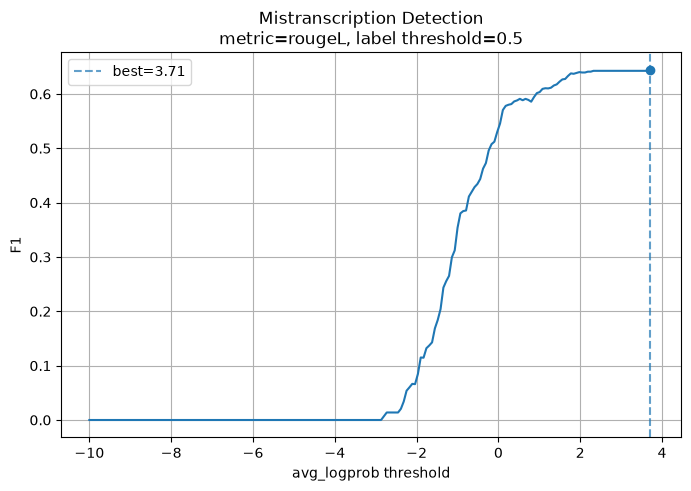

In [70]:
elbow_plot(filtered_df, metric_to_use='rougeL', mistranscription_label_threshold=0.5)

Best threshold: 0.5174
ROCAUC: 0.20648534917540767
Best F1: 0.7302
Precision at best F1: 0.6736
Recall at best F1: 0.7972



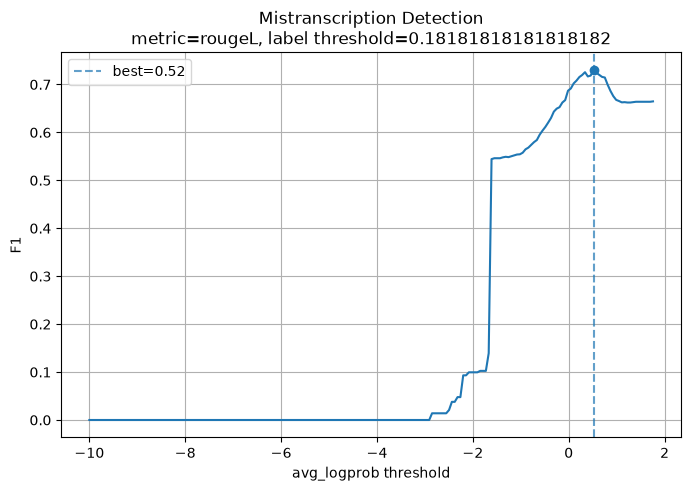

In [72]:
elbow_plot(df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)

Best threshold: 3.7104
ROCAUC: 0.44594460227272725
Best F1: 0.4190
Precision at best F1: 0.2654
Recall at best F1: 0.9938



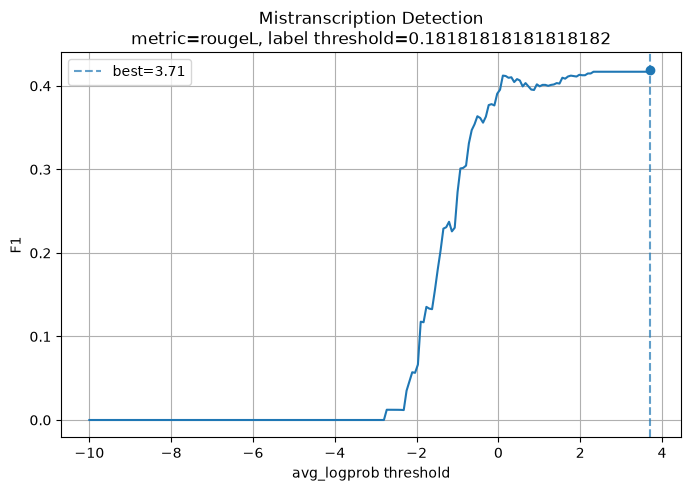

In [73]:
elbow_plot(filtered_df, metric_to_use='rougeL', mistranscription_label_threshold=rougeL_fifty)